In [1]:
# Lets generate data with outliers
import numpy as np

np.random.seed(23)
size=100

# Generates size samples of 2D data points from a standard normal distribution (N(0,1)).
# Scales the points by 0.3 → the cluster is tight/compact. These points are centered at (0, 0), but small spread.
X_inliers = 0.3 * np.random.randn(size, 2)


# Creates two clusters:
# X_inliers + 2 → shifts all points by (2, 2). Cluster centered at (2, 2).
# X_inliers - 2 → shifts all points by (-2, -2). Cluster centered at (-2, -2).
# np.r_ vertically stacks the two groups → final inliers = 200 points (100 at (2,2) + 100 at (-2,-2)).
X_inliers = np.r_[X_inliers + 2, X_inliers - 2]

# Generates 20 outlier points.
# Each coordinate is sampled uniformly between -4 and 4 → they can appear anywhere in this square region.
size_outliers = 20
X_outliers = np.random.uniform(low=-4, high=4, size=(size_outliers, 2))

X = np.r_[X_inliers, X_outliers] # Combines inliers and outliers into a single dataset X.
print(f"count: {len(X)}")
print(X[:10])

# create label to compare with prediction: 1 as inliers, -1 as outliers
n_outliers = len(X_outliers)
ground_truth = np.ones(len(X), dtype=int)
ground_truth[-n_outliers:] = -1
print(f"count:{len(ground_truth)}")
print(f"ground_truth: \n{ground_truth}")

count: 220
[[2.20009642 2.00774392]
 [1.76671418 2.28459015]
 [2.21050154 1.68467553]
 [1.88973557 1.65876209]
 [1.60335574 2.53167748]
 [1.8957623  2.20104205]
 [2.09668146 2.01810288]
 [1.686965   1.69701744]
 [2.13252091 2.33866306]
 [1.44857967 1.71836941]]
count:220
ground_truth: 
[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1]


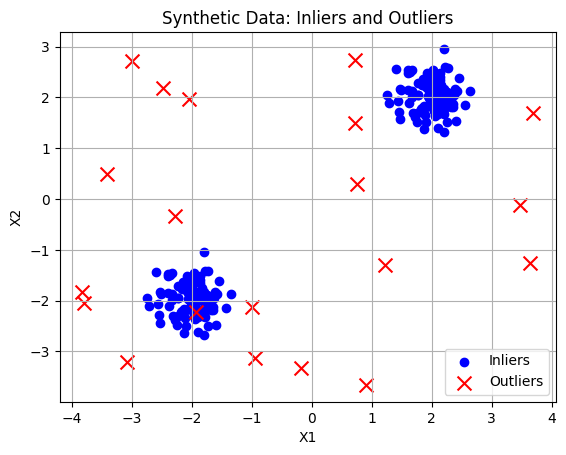

In [2]:
# OPTIONAL Lets plot above
import matplotlib.pyplot as plt

plt.scatter(X_inliers[:, 0], X_inliers[:, 1], c='blue', marker='o', label='Inliers')

# comment each one out to see
# plt.scatter(X_outliers[:, 0], X_outliers[:, 1], c='blue', marker='o')
plt.scatter(X_outliers[:, 0], X_outliers[:, 1], c='red', marker='x', s=100, label='Outliers')

plt.title("Synthetic Data: Inliers and Outliers")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.grid(True)

plt.show()


In [3]:
# Find outliers using LOF
from sklearn.neighbors import LocalOutlierFactor

# contamination=0.1: Tell LOF that you expect about 10% of your data 
# are outliers → this helps it set a threshold to separate inliers and outliers.
clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
y_pred = clf.fit_predict(X)

n_errors = (y_pred != ground_truth).sum()
print(n_errors)
X_scores = clf.negative_outlier_factor_
print(X_scores)

4
[-0.98664939 -1.05558869 -1.07702658 -1.06496069 -1.28786524 -0.9999016
 -0.96409173 -1.202232   -1.05727624 -1.32101117 -1.01593562 -1.01894744
 -0.99944746 -1.01950932 -1.06023457 -1.25321972 -1.33055053 -1.0788392
 -1.45044305 -0.98317049 -1.00602054 -0.97476297 -0.95414649 -1.04944927
 -1.01456034 -0.95624641 -0.9731658  -1.21928181 -1.04628662 -1.01812532
 -0.9775127  -0.98351512 -1.04789137 -1.96929344 -1.18173288 -1.089654
 -1.08021496 -0.98056796 -0.96880564 -0.97543779 -1.01329698 -1.37779219
 -1.13866761 -1.72539002 -0.9867208  -0.98029144 -1.00935724 -1.07078371
 -1.20559004 -1.24204072 -1.25742971 -1.27915757 -0.9642794  -1.25239288
 -1.492051   -1.36000677 -1.10441595 -1.20946705 -0.98483358 -1.05079222
 -1.15023892 -1.0087716  -1.62945546 -1.41164802 -0.94914991 -1.45358018
 -1.59702063 -1.00837686 -1.24563291 -1.09191536 -1.21813712 -1.06964253
 -1.23118054 -0.96459971 -0.9836031  -0.98657444 -0.94517361 -1.01369669
 -0.9420707  -0.95079362 -0.98286503 -1.28058273 -0.9

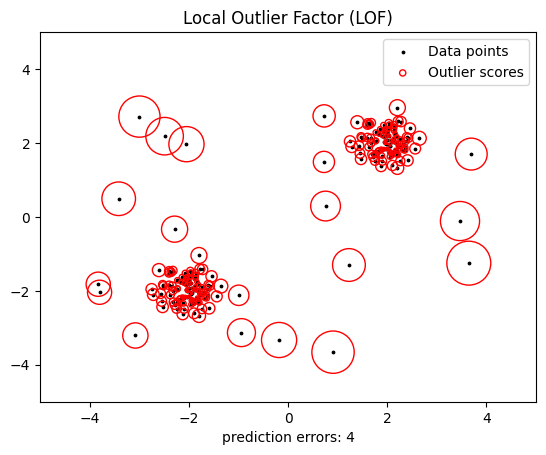

In [5]:
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerPathCollection


def update_legend_marker_size(handle, orig):
    "Customize size of the legend marker"
    handle.update_from(orig)
    handle.set_sizes([20])


plt.scatter(X[:, 0], X[:, 1], color="k", s=3.0, label="Data points")
# plot circles with radius proportional to the outlier scores
radius = (X_scores.max() - X_scores) / (X_scores.max() - X_scores.min())
scatter = plt.scatter(
    X[:, 0],
    X[:, 1],
    s=1000 * radius,
    edgecolors="r",
    facecolors="none",
    label="Outlier scores",
)
plt.axis("tight")
plt.xlim((-5, 5))
plt.ylim((-5, 5))
plt.xlabel("prediction errors: %d" % (n_errors))
plt.legend(
    handler_map={scatter: HandlerPathCollection(update_func=update_legend_marker_size)}
)
plt.title("Local Outlier Factor (LOF)")
plt.show()